# Validation of External Magnetic Field Support in Puffin

## 1. Introduction

### This notebook demonstrates how to generate an analytical planar undulator magnetic field, export it to the HDF5 format required by Puffin, and validate the imported field against Puffin's built-in analytical undulator model.

### The notebook ***does not*** validate the physical correctness of the magnetic field itself. Instead, it validates the implementation of the external magnetic field capability by comparing simulations using identical magnetic fields described in two different ways.

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.constants import e, m_e, c, pi

## 3. Analytical Planar Undulator Field

Puffin contains an analytical model of a planar undulator. This notebook recreates
the same magnetic field and exports it in the HDF5 format required by the
external magnetic field implementation.

The analytical magnetic field is

\[
B_x = 0
\]

\[
B_y = B_0 \cosh(k_u y)\sin(k_u z)
\]

\[
B_z = B_0 \sinh(k_u y)\cos(k_u z)
\]

where

\[
k_u=\frac{2\pi}{\lambda_u}.
\]

A linear entrance and exit taper is optionally applied to reproduce the
finite undulator ends used by Puffin.

## Simulation Parameters

In [2]:
def K_to_B0(K, lambda_u):
    """
    Convert undulatbor parameter K to peak magnetic field B0 [T].
    """
    return (2 * pi * m_e * c * K) / (e * lambda_u)


def B0_to_K(B0, lambda_u):
    """
    Convert peak magnetic field B0 [T] to undulator parameter K.
    """
    return (e * B0 * lambda_u) / (2 * pi * m_e * c)

In [7]:
# ------------------------------------------------------------
# Undulator parameters
# ------------------------------------------------------------

lambda_u = 0.1      # Undulator period [m]
K = 10              # Undulator parameter
N_periods = 90

# Convert K to the magnetic field amplitude used by Puffin
B0 = K_to_B0(K, lambda_u)

# Undulator wave number
ku = 2 * np.pi / lambda_u


# ------------------------------------------------------------
# Field mesh parameters
# ------------------------------------------------------------

Nx = 51                      # Number of points in x
Ny = 51                      # Number of points in y
Nz = 90 * N_periods          # Number of points in z

x_extent = 1.0e-3            # Half-width in x [m]
y_extent = 1.0e-3            # Half-width in y [m]

# Generate coordinate arrays
x = np.linspace(-x_extent, x_extent, Nx)
y = np.linspace(-y_extent, y_extent, Ny)
z = np.linspace(0, N_periods * lambda_u, Nz)

# Mesh spacing
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

print("Undulator parameters")
print("---------------------")
print(f"Period            : {lambda_u:.4f} m")
print(f"K                 : {K:.3f}")
print(f"B0                : {B0:.4f} T")
print(f"Number of periods : {N_periods}")

print("\nField mesh")
print("----------")
print(f"Nx = {Nx:4d}, Ny = {Ny:4d}, Nz = {Nz:4d}")
print(f"dx = {dx:.3e} m")
print(f"dy = {dy:.3e} m")
print(f"dz = {dz:.3e} m")
print(f"Points per period = {Nz / N_periods:.1f}")

Undulator parameters
---------------------
Period            : 0.1000 m
K                 : 10.000
B0                : 1.0710 T
Number of periods : 90

Field mesh
----------
Nx =   51, Ny =   51, Nz = 8100
dx = 4.000e-05 m
dy = 4.000e-05 m
dz = 1.111e-03 m
Points per period = 90.0


## Creating the Magnetic Field Mesh

The magnetic field is defined on a uniformly spaced Cartesian mesh. The
coordinate arrays are written directly to the HDF5 file and define the
locations of the magnetic field samples.

The x and y axes are centred on zero and extend sufficiently beyond the
electron beam to ensure that all particles remain within the field map during
the simulation.

In [8]:
# ------------------------------------------------------------
# Create magnetic field mesh
# ------------------------------------------------------------

# Coordinate arrays
x = np.linspace(-x_extent, x_extent, Nx)
y = np.linspace(-y_extent, y_extent, Ny)
z = np.linspace(0.0, N_periods * lambda_u, Nz)

# Mesh spacing
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

print("Mesh dimensions")
print("----------------")
print(f"x : {x[0]:.4e} to {x[-1]:.4e} m ({Nx} points)")
print(f"y : {y[0]:.4e} to {y[-1]:.4e} m ({Ny} points)")
print(f"z : {z[0]:.4e} to {z[-1]:.4e} m ({Nz} points)")

print("\nMesh spacing")
print("------------")
print(f"dx = {dx:.3e} m")
print(f"dy = {dy:.3e} m")
print(f"dz = {dz:.3e} m")

Mesh dimensions
----------------
x : -1.0000e-03 to 1.0000e-03 m (51 points)
y : -1.0000e-03 to 1.0000e-03 m (51 points)
z : 0.0000e+00 to 9.0000e+00 m (8100 points)

Mesh spacing
------------
dx = 4.000e-05 m
dy = 4.000e-05 m
dz = 1.111e-03 m


## Calculate the Magnetic Field

The analytical planar undulator field is evaluated at every point of the
Cartesian mesh. A linear taper is applied over the first and last two
undulator periods to reproduce the finite undulator ends used in Puffin.

In [9]:
# ------------------------------------------------------------
# Calculate magnetic field (vectorized)
# ------------------------------------------------------------

# Taper as a function of z only (1D array of length Nz)
taper = np.ones_like(z)
taper = np.where(z <= 2 * lambda_u, z / (2 * lambda_u), taper)
taper = np.where(
    z >= (N_periods - 2) * lambda_u,
    -(z - (N_periods - 2) * lambda_u) / (2 * lambda_u) + 1,
    taper,
)

# Build 2D (Ny, Nz) grids for y and z
Y, Z = np.meshgrid(y, z, indexing="ij")   # shapes (Ny, Nz)

By_2d = taper[np.newaxis, :] * B0 * np.sin(ku * Z) * np.cosh(ku * Y)
Bz_2d = taper[np.newaxis, :] * B0 * np.cos(ku * Z) * np.sinh(ku * Y)

# Broadcast across x (no x-dependence in the fields)
Bx = np.zeros((Nx, Ny, Nz))
By = np.broadcast_to(By_2d, (Nx, Ny, Nz)).copy()
Bz = np.broadcast_to(Bz_2d, (Nx, Ny, Nz)).copy()

print("\nMagnetic field successfully generated.")


Magnetic field successfully generated.


In [10]:
# -------------------------------------------------------------------
# Equivalent non-vectorized implementation (reference only)
#
# The magnetic field above is calculated using NumPy vectorization
# for efficiency. The loop-based implementation below performs the
# same calculation and may be easier to modify when implementing
# more complicated magnetic field distributions.
#
# This code is provided for illustration and does not need to be run.
# To execute it, change "if False:" to "if True:".
# -------------------------------------------------------------------

if False:

    # ------------------------------------------------------------
    # Initialise magnetic field arrays
    # ------------------------------------------------------------

    Bx = np.zeros((Nx, Ny, Nz))
    By = np.zeros((Nx, Ny, Nz))
    Bz = np.zeros((Nx, Ny, Nz))

    # ------------------------------------------------------------
    # Calculate magnetic field
    # ------------------------------------------------------------

    for ix in range(Nx):
        for iy in range(Ny):
            for iz in range(Nz):

                # Linear taper over the first and last two periods
                if z[iz] <= 2 * lambda_u:
                    taper = z[iz] / (2 * lambda_u)

                elif z[iz] >= (N_periods - 2) * lambda_u:
                    taper = (
                        -(z[iz] - (N_periods - 2) * lambda_u)
                        / (2 * lambda_u)
                        + 1
                    )

                else:
                    taper = 1.0

                Bx[ix, iy, iz] = 0.0

                By[ix, iy, iz] = (
                    taper
                    * B0
                    * np.sin(ku * z[iz])
                    * np.cosh(ku * y[iy])
                )

                Bz[ix, iy, iz] = (
                    taper
                    * B0
                    * np.cos(ku * z[iz])
                    * np.sinh(ku * y[iy])
                )

## 4. Visulase the Magnetic Field

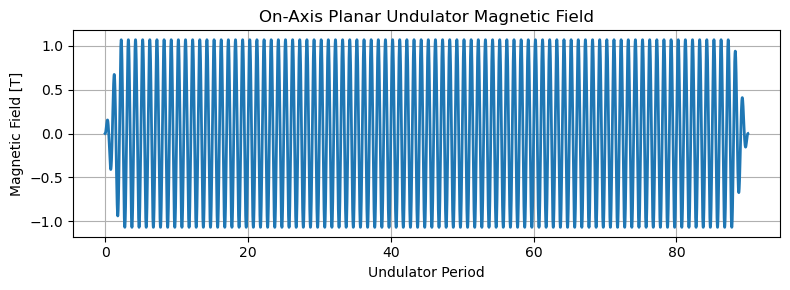

In [11]:
# ------------------------------------------------------------
# On-axis magnetic field
# ------------------------------------------------------------

mid_x = Nx // 2
mid_y = Ny // 2

plt.figure(figsize=(8, 3))

plt.plot(
    z / lambda_u,
    By[mid_x, mid_y, :],
    lw=2,
    label=r"$B_y$",
)

plt.xlabel("Undulator Period")
plt.ylabel("Magnetic Field [T]")
plt.title("On-Axis Planar Undulator Magnetic Field")
plt.grid(True)
plt.tight_layout()
plt.savefig('On-axis_B.png')
plt.show()

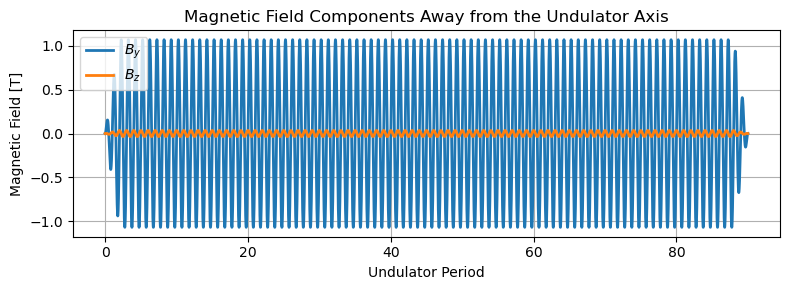

In [12]:
# ------------------------------------------------------------
# Off-axis magnetic field
# ------------------------------------------------------------

mid_x = Nx // 2
off_y = int(0.75 * Ny)     # Select a point away from the undulator axis

plt.figure(figsize=(8, 3))

plt.plot(
    z / lambda_u,
    By[mid_x, off_y, :],
    lw=2,
    label=r"$B_y$",
)

plt.plot(
    z / lambda_u,
    Bz[mid_x, off_y, :],
    lw=2,
    label=r"$B_z$",
)

plt.xlabel("Undulator Period")
plt.ylabel("Magnetic Field [T]")
plt.title("Magnetic Field Components Away from the Undulator Axis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

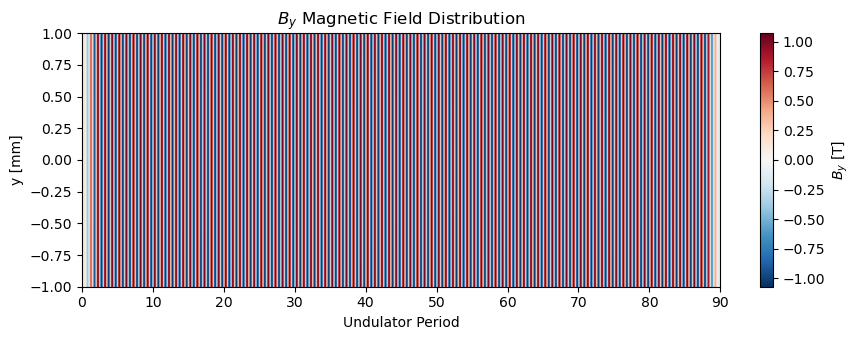

In [14]:
# ------------------------------------------------------------
# y-z slice of By
# ------------------------------------------------------------

mid_x = Nx // 2

plt.figure(figsize=(9, 3.5))

plt.imshow(
    By[mid_x, :, :],
    extent=[0, N_periods, y[0]*1e3, y[-1]*1e3],
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
)

plt.colorbar(label=r"$B_y$ [T]")
plt.xlabel("Undulator Period")
plt.ylabel("y [mm]")
plt.title(r"$B_y$ Magnetic Field Distribution")
plt.tight_layout()
plt.show()

## 5. Export the Magnetic Field

The magnetic field arrays and coordinate vectors are written to an HDF5 file.
This is the format required by the external magnetic field implementation in
Puffin.

The file contains six datasets:

- `Bx` – x-component of the magnetic field [T]
- `By` – y-component of the magnetic field [T]
- `Bz` – z-component of the magnetic field [T]
- `x` – x coordinates [m]
- `y` – y coordinates [m]
- `z` – z coordinates [m]

In [15]:
# ------------------------------------------------------------
# Export magnetic field to HDF5
# ------------------------------------------------------------

filename = "planar_validation.h5"

with h5py.File(filename, "w") as h5:
    h5.create_dataset("Bx", data=Bx)
    h5.create_dataset("By", data=By)
    h5.create_dataset("Bz", data=Bz)

    h5.create_dataset("x", data=x)
    h5.create_dataset("y", data=y)
    h5.create_dataset("z", data=z)

print(f"Magnetic field successfully written to '{filename}'.")

Magnetic field successfully written to 'planar_validation.h5'.


## Verify the HDF5 File

Open the generated file and verify that the expected datasets have been
written.

In [16]:
with h5py.File(filename, "r") as h5:

    print("Datasets")
    print("--------")

    for key in h5.keys():
        print(f"{key:2s} : {h5[key].shape}")

Datasets
--------
Bx : (51, 51, 8100)
By : (51, 51, 8100)
Bz : (51, 51, 8100)
x  : (51,)
y  : (51,)
z  : (8100,)
